In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loding the data to dataframes
df_rating = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/ratings.dat',
                         sep='::', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'])
df_user = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/users.dat',
                       sep='::', header=None, names=['user_id', 'gender', 'age', 'occupation', 'zipcode'])
df_movie = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/movies.dat',
                        sep='::', encoding='latin-1', engine='python', header=None, 
                        names=['movie_id', 'title', 'genre'])

In [3]:
print(df_movie.head())
print(df_user.head())
print(df_rating.head())
# check the shape of the dataframes
print("Shape of df_movie: ", df_movie.shape)
print("Shape of df_user: ", df_user.shape)
print("Shape of df_rating: ", df_rating.shape)
# check the data types of the dataframes
print("Data types of df_movie: ", df_movie.dtypes)
print("Data types of df_user: ", df_user.dtypes)
print("Data types of df_rating: ", df_rating.dtypes)

   movie_id                               title                         genre
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy
   user_id gender  age  occupation zipcode
0        1      F    1          10   48067
1        2      M   56          16   70072
2        3      M   25          15   55117
3        4      M   45           7   02460
4        5      M   25          20   55455
   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291
Shape of df_movie:  (3883, 3)
Shap

In [4]:
# Age group dictionary 
#retrieved from dataset description
age_group_dict = {
    1:  "Under 18",
    18:  "18-24",
    25:  "25-34",
    35:  "35-44",
    45:  "45-49",
    50:  "50-55",
    56:  "56+"
}

In [5]:
# Occupation dictionary retrieved from dataset description
occupation_dict = {
    0:  "other or not specified",
    1:  "academic/educator",
    2:  "artist",
    3:  "clerical/admin",
    4:  "college/grad student",
    5:  "customer service",
    6:  "doctor/health care",
    7:  "executive/managerial",
    8:  "farmer",
    9:  "homemaker",
    10:  "K-12 student",
    11:  "lawyer",
    12:  "programmer",
    13:  "retired",
    14:  "sales/marketing",
    15:  "scientist",
    16:  "self-employed",
    17:  "technician/engineer",
    18:  "tradesman/craftsman",
    19:  "unemployed",
    20:  "writer"
}

Rating

In [6]:
df_rating.head()


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [7]:
df_rating.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [8]:
df_rating['timestamp'] = df_rating['timestamp'].apply(datetime.fromtimestamp)
df_rating['year'] = df_rating['timestamp'].dt.year
df_rating['month'] = df_rating['timestamp'].dt.month
df_rating['date'] = df_rating['timestamp'].dt.date
df_rating = df_rating.sort_values('timestamp').reset_index(drop=True)

In [9]:
df_rating.head()


,user_id,movie_id,rating,timestamp,year,month,date
0,6040,858,4,2000-04-26 06:05:32,2000,4,2000-04-26
1,6040,2384,4,2000-04-26 06:05:54,2000,4,2000-04-26
2,6040,593,5,2000-04-26 06:05:54,2000,4,2000-04-26
3,6040,1961,4,2000-04-26 06:06:17,2000,4,2000-04-26
4,6040,2019,5,2000-04-26 06:06:17,2000,4,2000-04-26


In [10]:
df_rating.tail()


,user_id,movie_id,rating,timestamp,year,month,date
1000204,4958,2399,1,2003-03-01 00:45:38,2003,3,2003-03-01
1000205,4958,1407,5,2003-03-01 00:47:23,2003,3,2003-03-01
1000206,4958,3264,4,2003-03-01 00:49:08,2003,3,2003-03-01
1000207,4958,2634,3,2003-03-01 00:49:08,2003,3,2003-03-01
1000208,4958,1924,4,2003-03-01 00:49:50,2003,3,2003-03-01


In [11]:
print('Years:', df_rating.year.unique())
print('Months', df_rating.month.unique())
print('#Unique users:', df_rating.user_id.nunique())
print('#Unique movies:', df_rating.movie_id.nunique())
print('Unique ratings:', df_rating.rating.unique())
print('Average rating:', round(df_rating.rating.mean(), 2))
print('Frequency of each rating value:')
print(df_rating['rating'].value_counts())

Years: [2000 2001 2002 2003]
Months [ 4  5  6  7  8  9 10 11 12  1  2  3]
#Unique users: 6040
#Unique movies: 3706
Unique ratings: [4 5 3 2 1]
Average rating: 3.58
Frequency of each rating value:
rating
4    348971
3    261197
5    226310
2    107557
1     56174
Name: count, dtype: int64


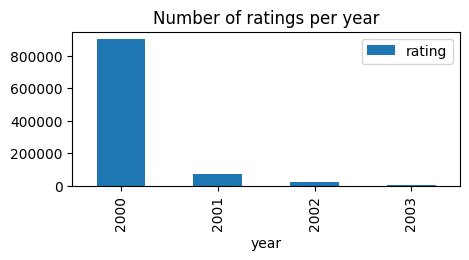

In [14]:
df_rating[['year', 'rating']].groupby(['year']).count().reset_index().plot.bar(x='year',y='rating', title='Number of ratings per year', figsize=(5,2));


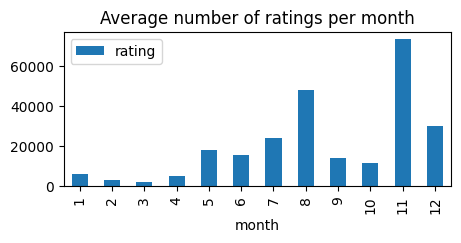

In [16]:
df_temp = df_rating[['month', 'rating']].groupby(['month']).count().reset_index()
df_temp['rating'] = df_temp['rating'] / 4
df_temp.plot.bar(x='month', y='rating', title='Average number of ratings per month', figsize=(5, 2));


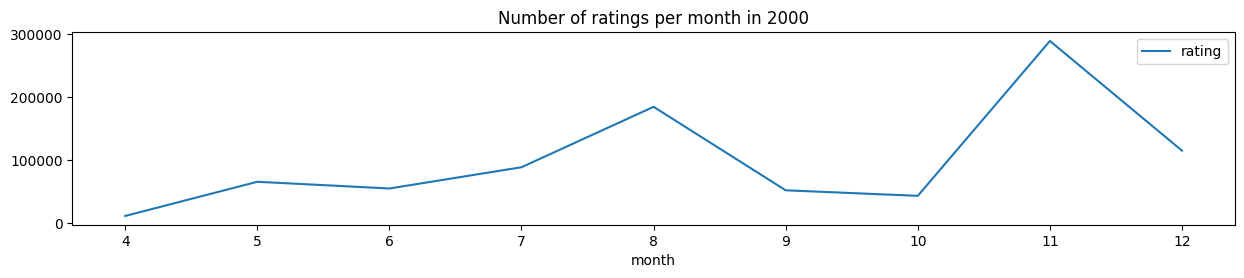

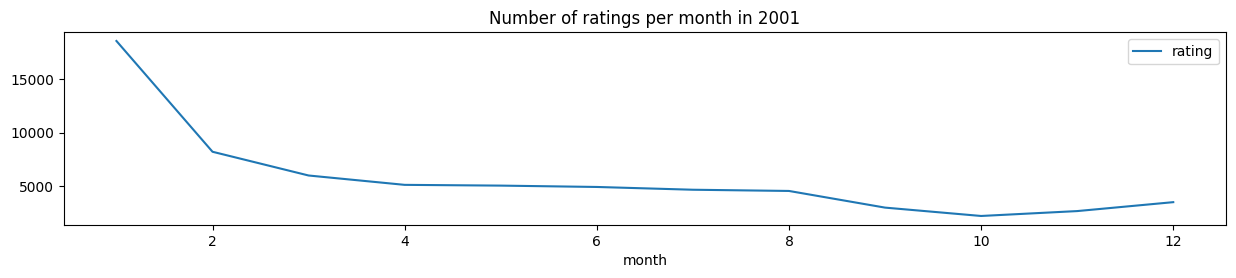

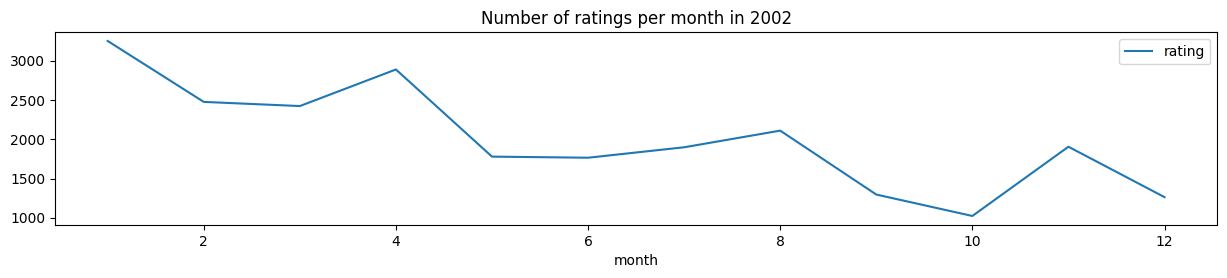

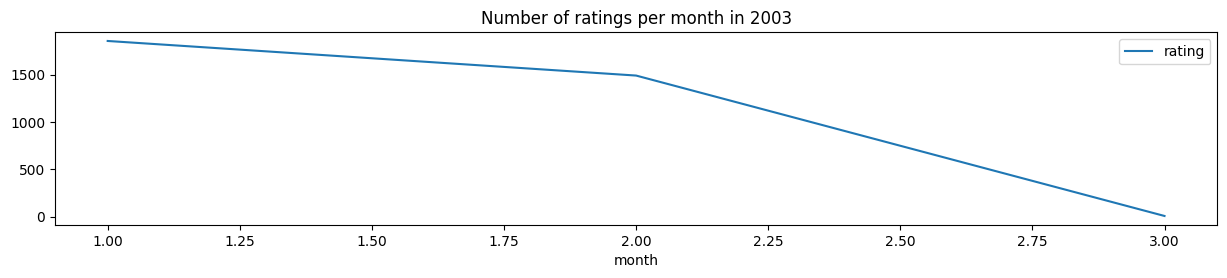

In [17]:
df_temp = df_rating[['year', 'month', 'rating']].groupby(['year', 'month']).count().reset_index()
for year in df_temp['year'].unique():
    df_temp.loc[df_temp['year'] == year].plot('month', 'rating', title='Number of ratings per month in %s' %year,
                                               figsize=(15, 2.5))

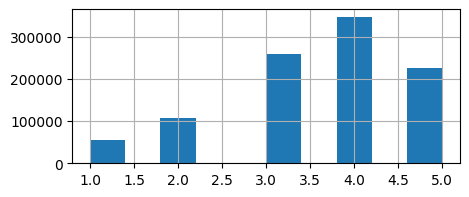

In [18]:
df_rating['rating'].hist(figsize=(5,2));


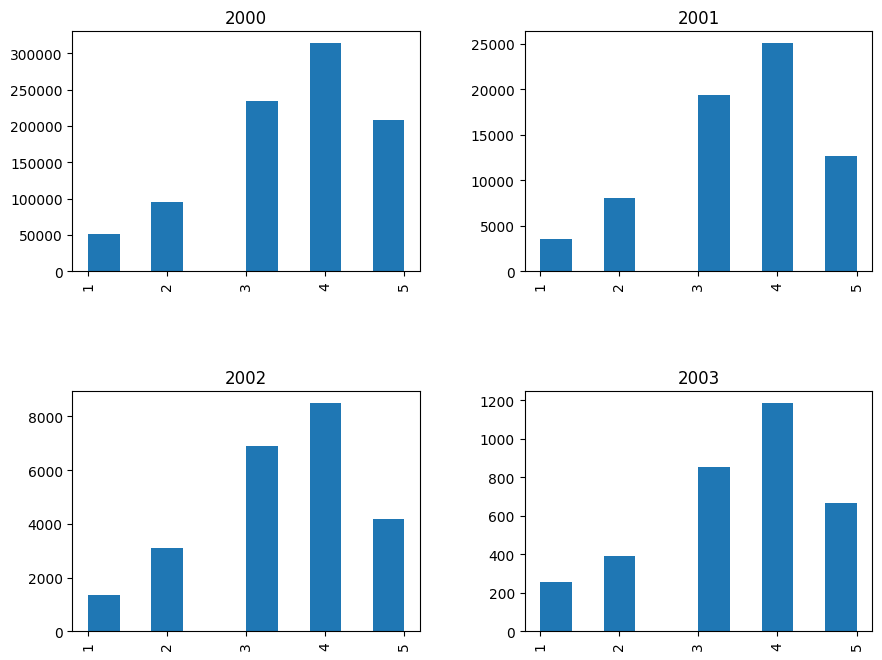

In [19]:
df_rating['rating'].hist(by=df_rating['year'], figsize=(10, 8));


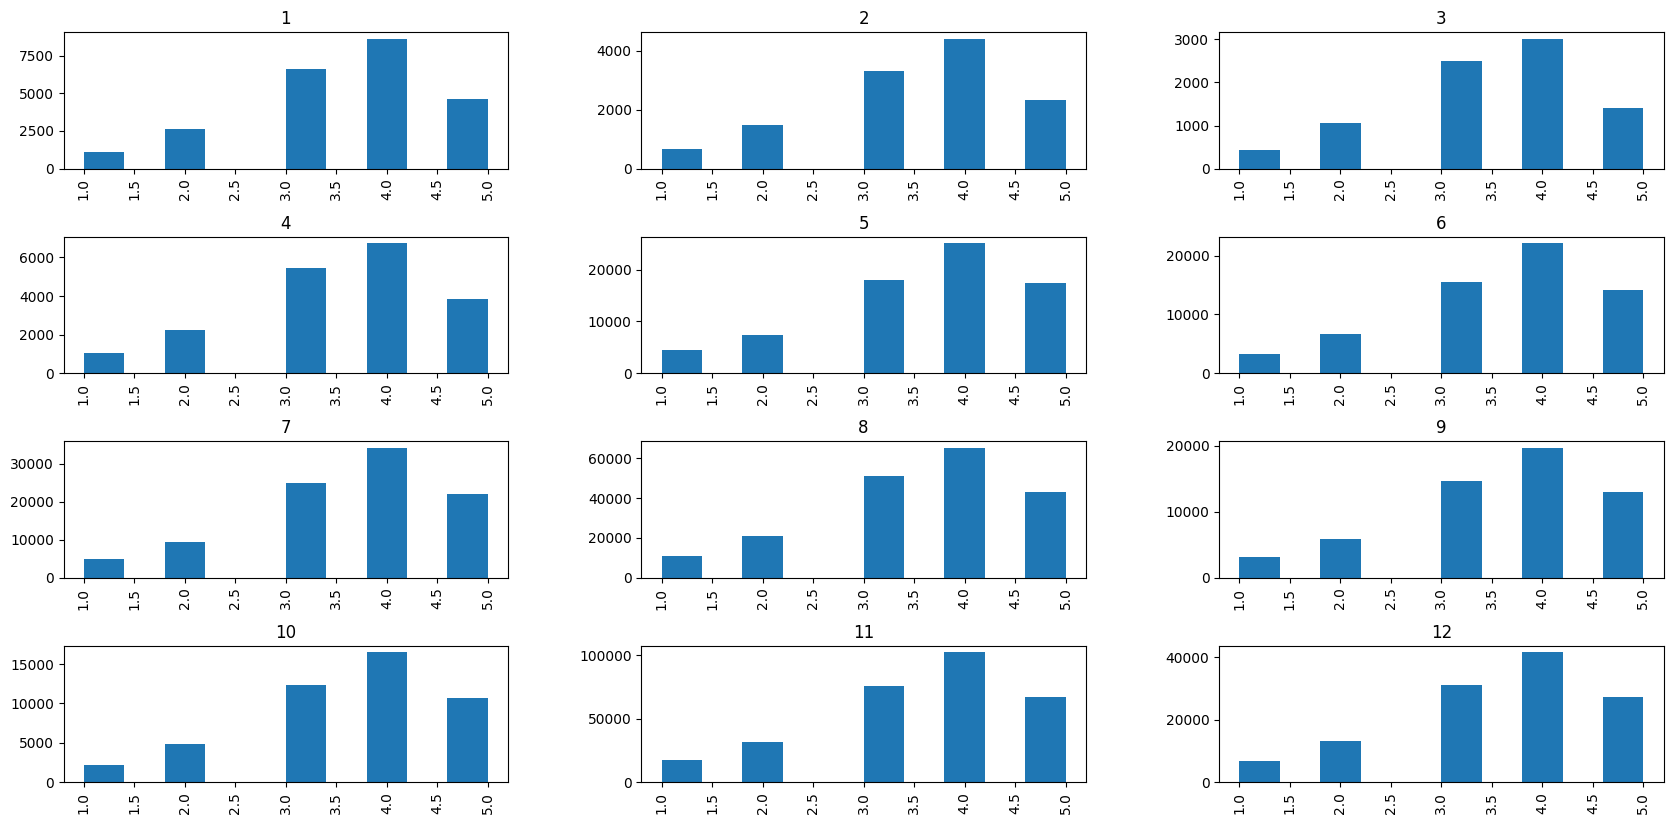

In [20]:
df_rating['rating'].hist(by=df_rating['month'], figsize=(20, 10));


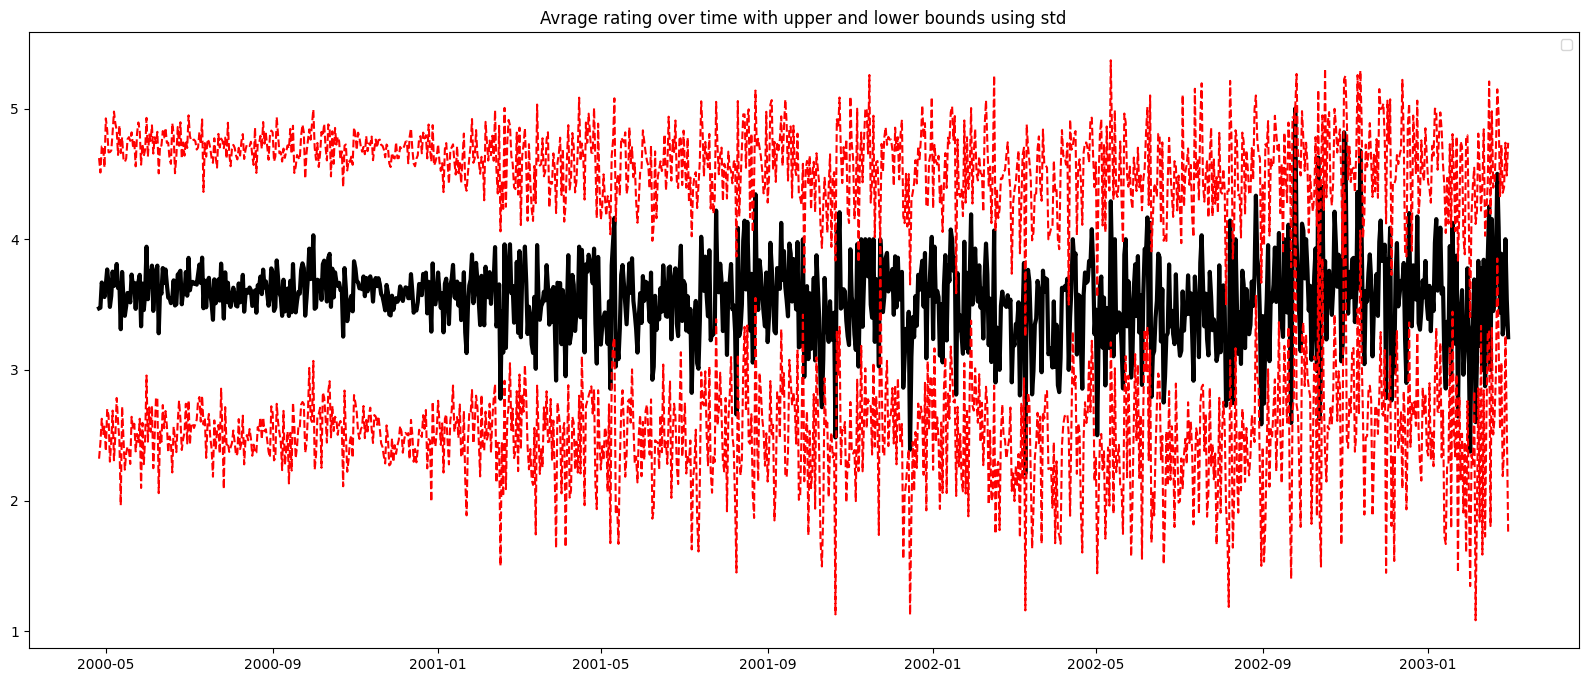

In [21]:
df_temp = df_rating.groupby(['date'])['rating'].agg([np.mean, np.std]).reset_index()
df_temp['upper'] = df_temp['mean'] + df_temp['std']
df_temp['lower'] = df_temp['mean'] - df_temp['std']
plt.figure(figsize=(20,8)) 
plt.plot(df_temp['date'], df_temp['mean'], color="black", linewidth=3.0)
plt.plot(df_temp['date'], df_temp['upper'], color="red", linestyle='--')
plt.plot(df_temp['date'], df_temp['lower'], color="red", linestyle='--')
plt.title('Avrage rating over time with upper and lower bounds using std')
plt.legend()
plt.show()

In [22]:
df_rating['user_id'].value_counts().nlargest(n=10)


user_id
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
Name: count, dtype: int64

In [23]:
type(df_rating['user_id'].value_counts())


pandas.core.series.Series

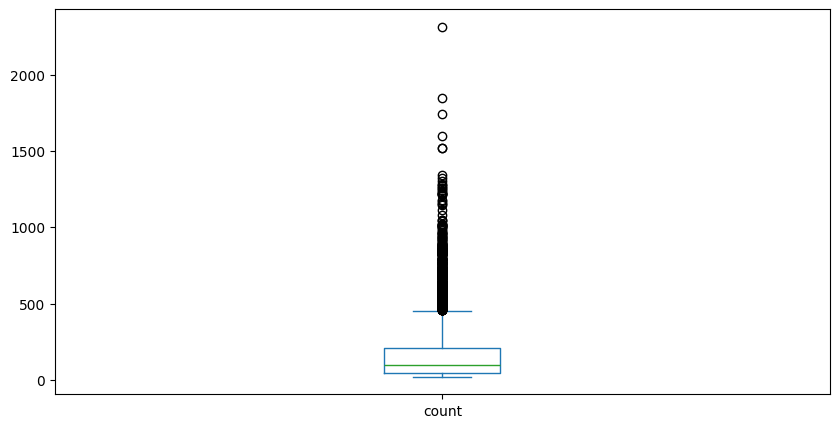

In [24]:
df_rating['user_id'].value_counts().plot.box(figsize=(10, 5));


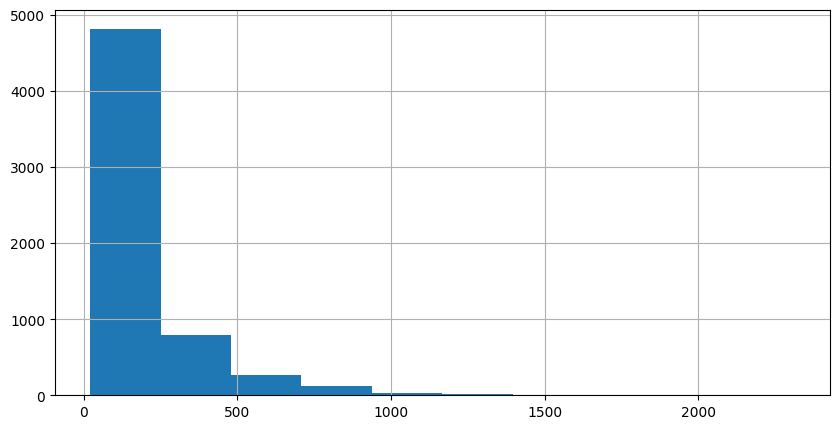

In [25]:
df_rating['user_id'].value_counts().hist(figsize=(10, 5));


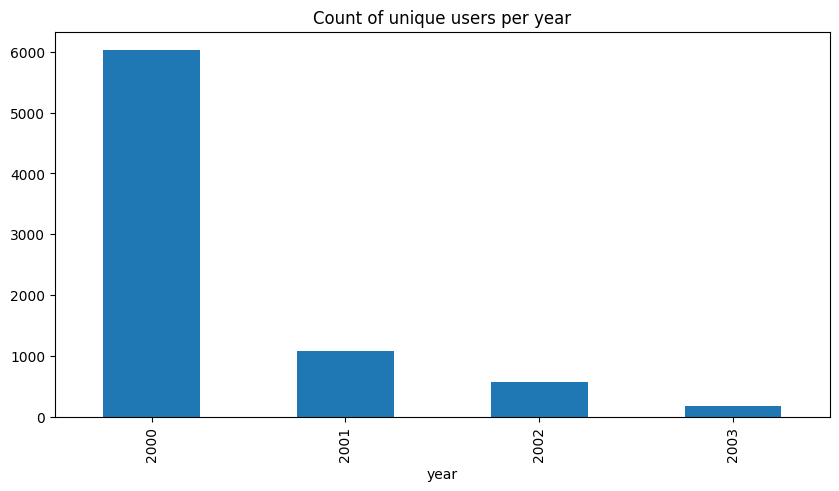

In [26]:
df_rating[['year', 'user_id']].groupby(['year'])['user_id'].nunique().plot.bar(x='year', 
                                                                               y='user_id', 
                                                                               title='Count of unique users' \
                                                                               ' per year', 
                                                                               figsize=(10, 5));


In [27]:
df_rating['movie_id'].value_counts().nlargest(n=10)


movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
Name: count, dtype: int64

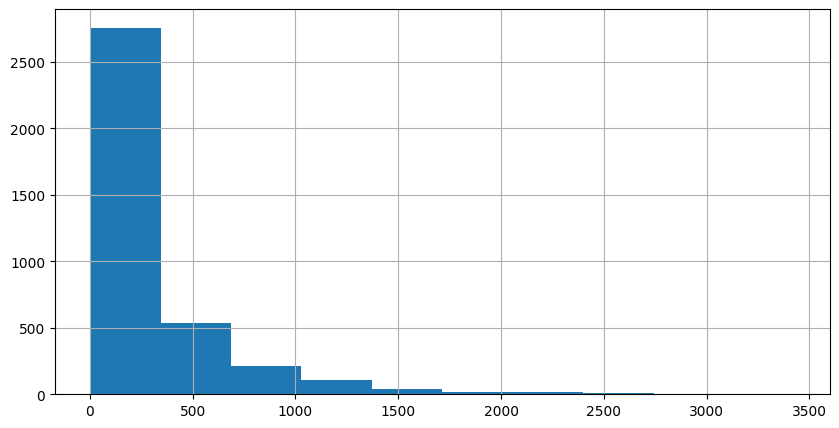

In [28]:
df_rating['movie_id'].value_counts().hist(figsize=(10, 5));


User

In [29]:
df_user.head()


,user_id,gender,age,occupation,zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [30]:
df_user.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     6040 non-null   int64 
 1   gender      6040 non-null   object
 2   age         6040 non-null   int64 
 3   occupation  6040 non-null   int64 
 4   zipcode     6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [31]:
print('#Unique occupation:', df_user.occupation.nunique())
print('#Unique zipcodes:', df_user.zipcode.nunique())
print('Gender distribution:\n', df_user['gender'].value_counts())

#Unique occupation: 21
#Unique zipcodes: 3439
Gender distribution:
 gender
M    4331
F    1709
Name: count, dtype: int64


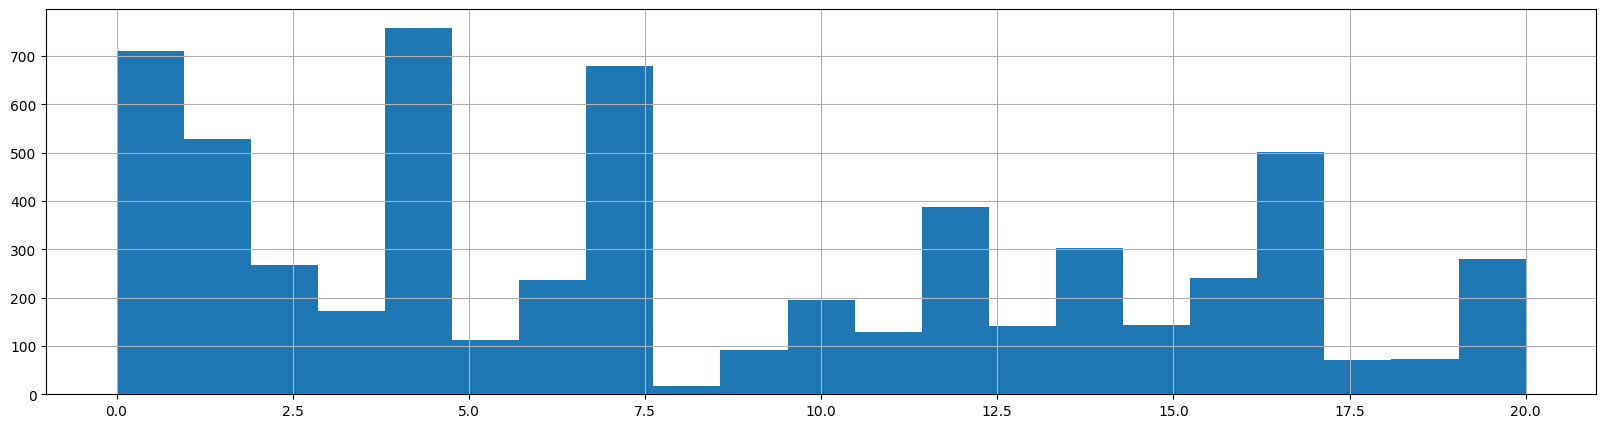

In [32]:
df_user['occupation'].hist(bins=21, figsize=(20, 5));


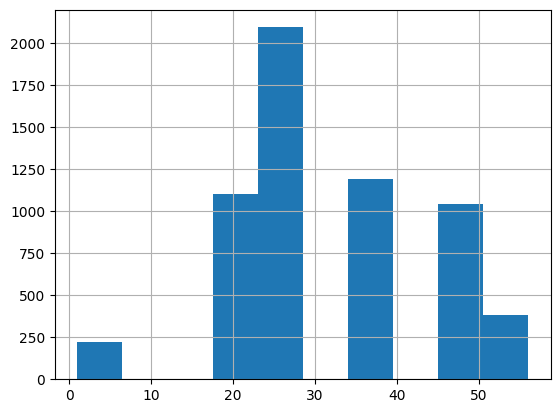

In [33]:
df_user['age'].hist();


Movie

In [34]:
df_movie.head()


,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [35]:
df_movie['release_year'] = df_movie.title.str.extract("\((\d{4})\)", expand=True).astype(str)


In [36]:
df_movie['release_year'] = pd.to_datetime(df_movie.release_year, format='%Y')
df_movie['release_year'] = df_movie.release_year.dt.year
df_movie['title'] = df_movie.title.str[:-7]

In [37]:
# Printing unique genres. This is also given in the dataset description file
genres_unique = pd.DataFrame(df_movie.genre.str.split('|').tolist()).stack().unique()
print('Unique genres', genres_unique)
genres_unique = pd.DataFrame(genres_unique, columns=['genre'])

Unique genres ['Animation' "Children's" 'Comedy' 'Adventure' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Sci-Fi' 'Documentary' 'War'
 'Musical' 'Mystery' 'Film-Noir' 'Western']


In [38]:
df_movie = df_movie.join(df_movie.genre.str.get_dummies().astype(bool))
df_movie.drop('genre', inplace=True, axis=1)

In [39]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie_id      3883 non-null   int64 
 1   title         3883 non-null   object
 2   release_year  3883 non-null   int32 
 3   Action        3883 non-null   bool  
 4   Adventure     3883 non-null   bool  
 5   Animation     3883 non-null   bool  
 6   Children's    3883 non-null   bool  
 7   Comedy        3883 non-null   bool  
 8   Crime         3883 non-null   bool  
 9   Documentary   3883 non-null   bool  
 10  Drama         3883 non-null   bool  
 11  Fantasy       3883 non-null   bool  
 12  Film-Noir     3883 non-null   bool  
 13  Horror        3883 non-null   bool  
 14  Musical       3883 non-null   bool  
 15  Mystery       3883 non-null   bool  
 16  Romance       3883 non-null   bool  
 17  Sci-Fi        3883 non-null   bool  
 18  Thriller      3883 non-null   bool  
 19  War   

In [40]:
df_movie.head()


,movie_id,title,release_year,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,1995,False,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,Jumanji,1995,False,True,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,3,Grumpier Old Men,1995,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,Waiting to Exhale,1995,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,Father of the Bride Part II,1995,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
print('#Unique movie release years:', df_movie.release_year.nunique())


#Unique movie release years: 81


In [42]:
temp = df_movie.release_year.unique()
temp.sort()
print(temp)


[1919 1920 1921 1922 1923 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000]


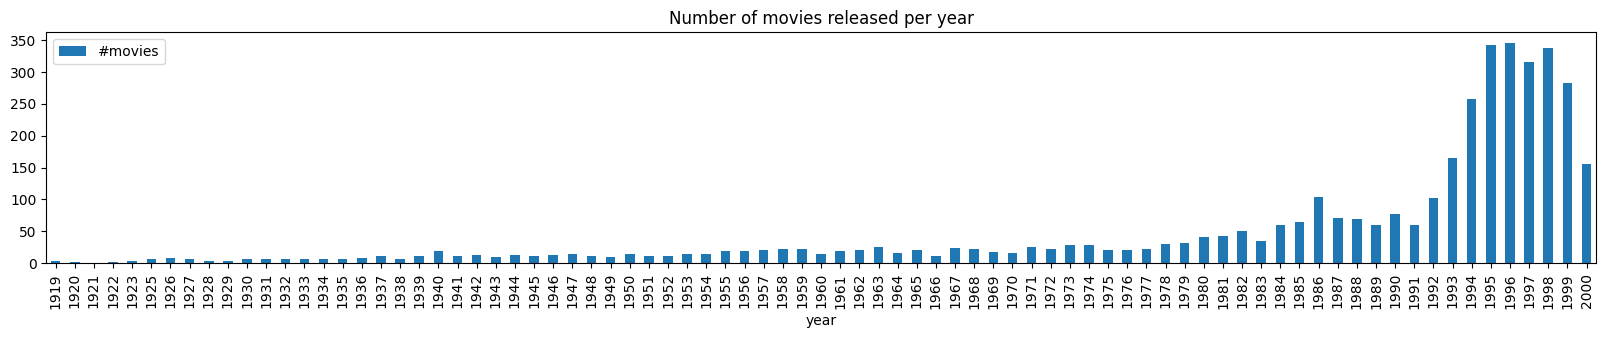

In [43]:
df_temp = df_movie[['release_year', 'movie_id']].groupby(['release_year']).count().reset_index().rename(
    columns={'release_year':'year', 'movie_id':'#movies'})
df_temp.plot.bar('year', '#movies', title='Number of movies released per year', figsize=(20, 3));

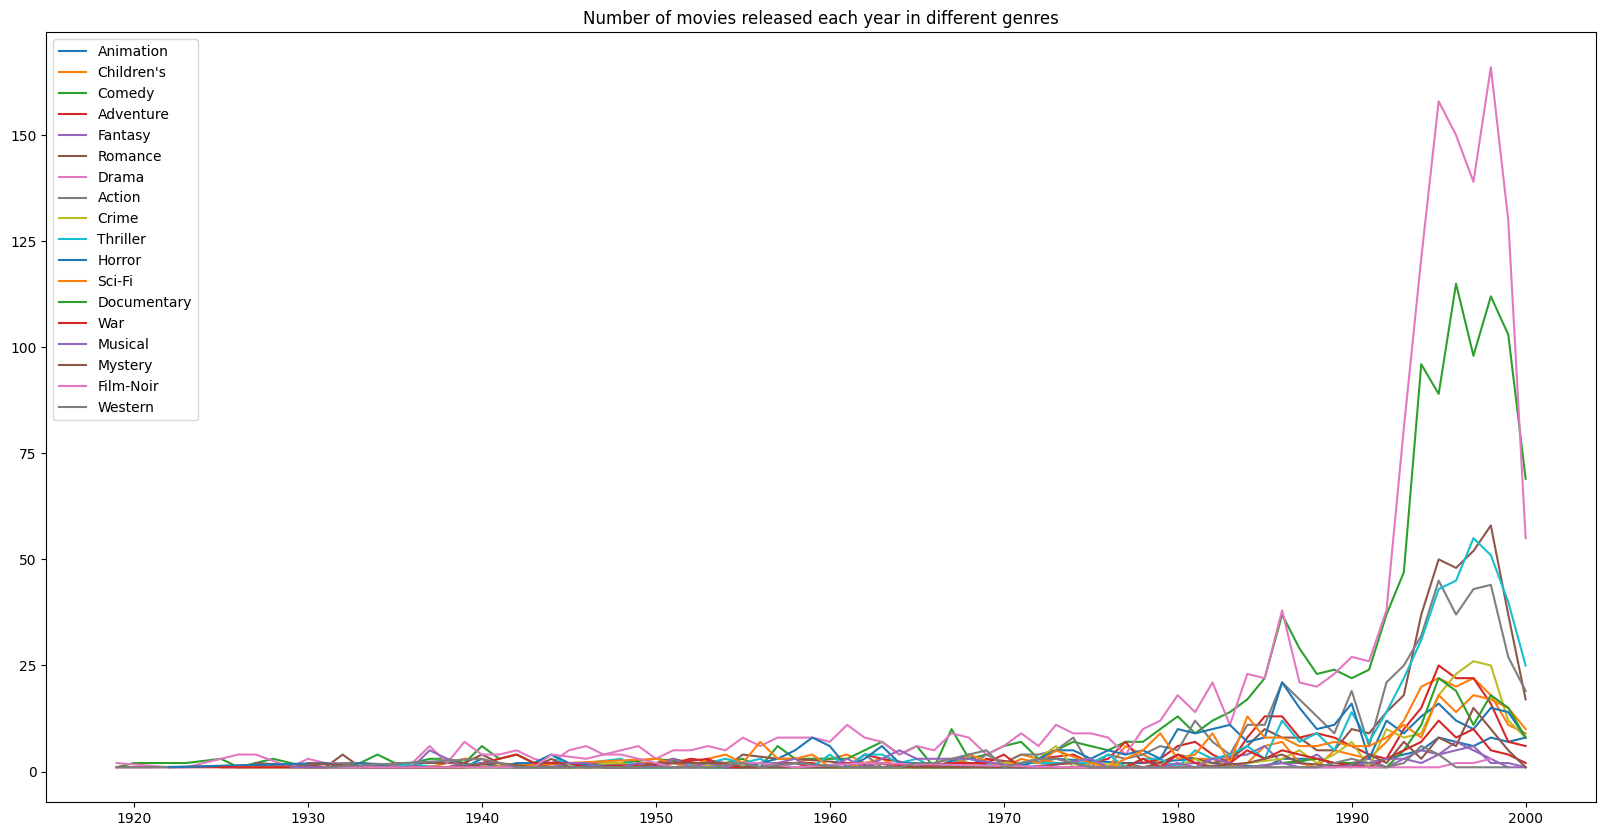

In [44]:
plt.figure(figsize=(20,10)) 
for genre in genres_unique.genre:
    df_temp = df_movie[df_movie[genre]==True][['release_year', 'movie_id']]
    df_temp = df_temp.groupby(['release_year']).count().reset_index().rename(columns={'release_year':'year', 
                                                                                      'movie_id':'#movies'})
    plt.plot(df_temp['year'], df_temp['#movies'], label=genre)
plt.title('Number of movies released each year in different genres')
plt.legend()
plt.show()

Kết hợp

In [45]:
df_temp = df_rating.merge(df_movie, left_on='movie_id', right_on='movie_id', how='left')
df_final = df_temp.merge(df_user, left_on='user_id', right_on='user_id', how='left')
df_final.head()

,user_id,movie_id,rating,timestamp,year,month,date,title,release_year,Action,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,gender,age,occupation,zipcode
0,6040,858,4,2000-04-26 06:05:32,2000,4,2000-04-26,"Godfather, The",1972,True,...,False,False,False,False,False,False,M,25,6,11106
1,6040,2384,4,2000-04-26 06:05:54,2000,4,2000-04-26,Babe: Pig in the City,1998,False,...,False,False,False,False,False,False,M,25,6,11106
2,6040,593,5,2000-04-26 06:05:54,2000,4,2000-04-26,"Silence of the Lambs, The",1991,False,...,False,False,False,True,False,False,M,25,6,11106
3,6040,1961,4,2000-04-26 06:06:17,2000,4,2000-04-26,Rain Man,1988,False,...,False,False,False,False,False,False,M,25,6,11106
4,6040,2019,5,2000-04-26 06:06:17,2000,4,2000-04-26,Seven Samurai (The Magnificent Seven) (Shichin...,1954,True,...,False,False,False,False,False,False,M,25,6,11106


In [46]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 31 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   user_id       1000209 non-null  int64         
 1   movie_id      1000209 non-null  int64         
 2   rating        1000209 non-null  int64         
 3   timestamp     1000209 non-null  datetime64[ns]
 4   year          1000209 non-null  int32         
 5   month         1000209 non-null  int32         
 6   date          1000209 non-null  object        
 7   title         1000209 non-null  object        
 8   release_year  1000209 non-null  int32         
 9   Action        1000209 non-null  bool          
 10  Adventure     1000209 non-null  bool          
 11  Animation     1000209 non-null  bool          
 12  Children's    1000209 non-null  bool          
 13  Comedy        1000209 non-null  bool          
 14  Crime         1000209 non-null  bool          
 15

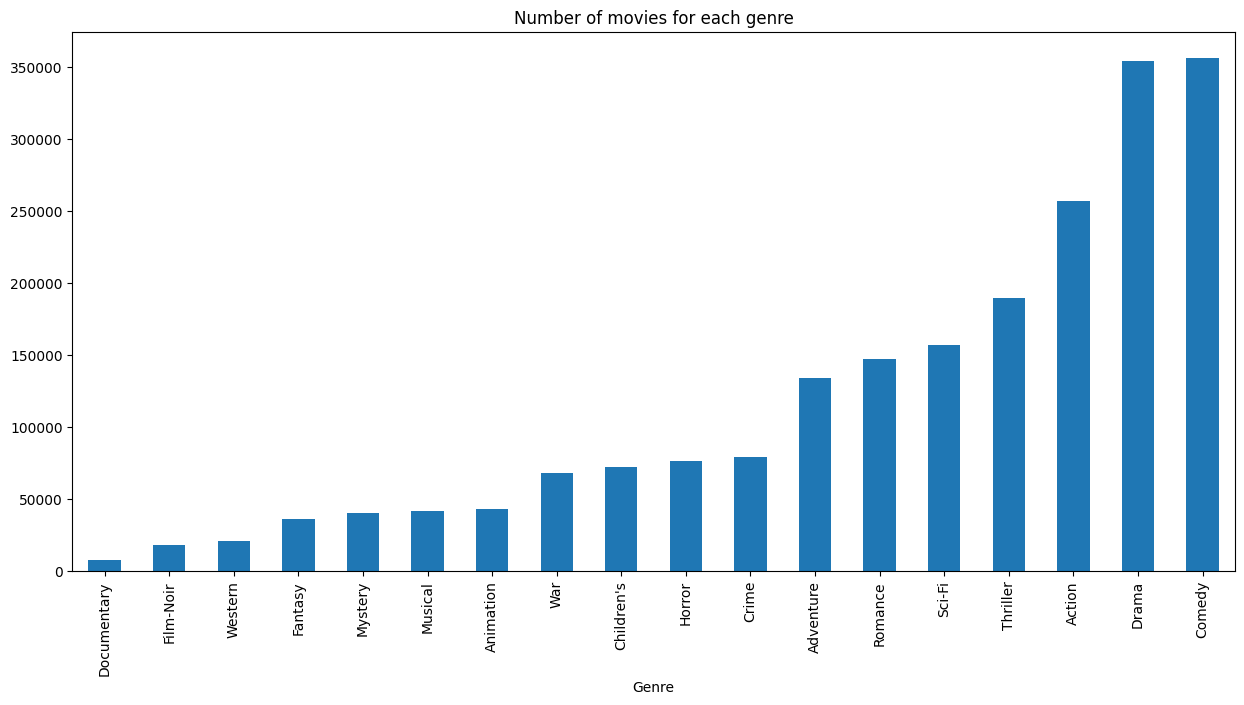

In [47]:
df_temp = pd.DataFrame(columns=['genre', 'num_movies'])
for genre in genres_unique.genre:
    row = [genre, df_final[df_final[genre]==True][['movie_id']].count()]
    df_temp.loc[len(df_temp)] = row
df_temp['num_movies'] = df_temp['num_movies'].astype(np.int32)
df_temp = df_temp.sort_values('num_movies', ascending=True).set_index('genre')
plot_fig = df_temp['num_movies'].plot(kind='bar', figsize=(15,7))
plot_fig.set_title('Number of movies for each genre')
plot_fig.set_xlabel('Genre');

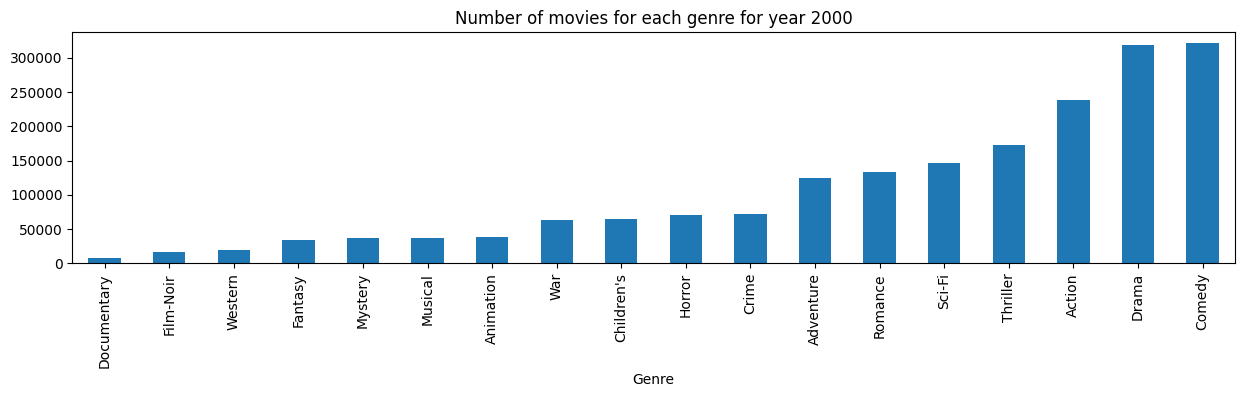

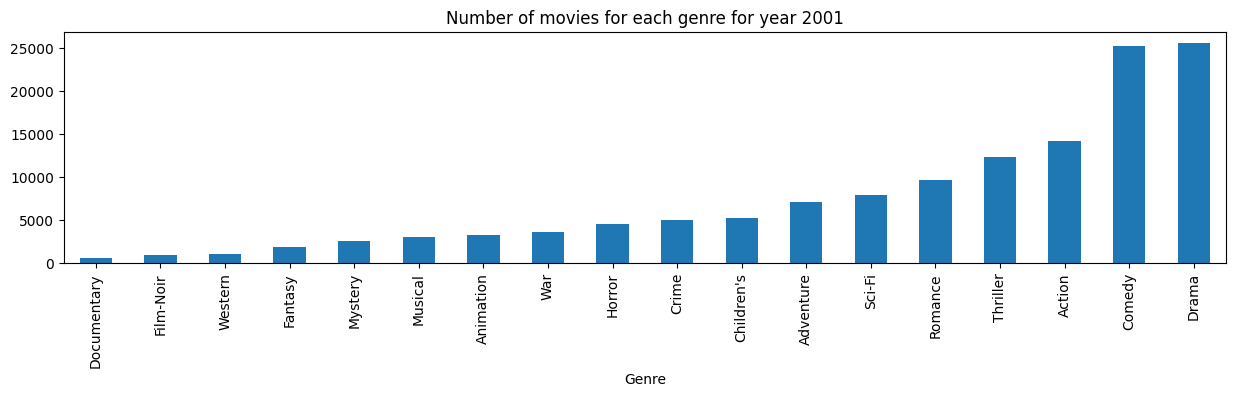

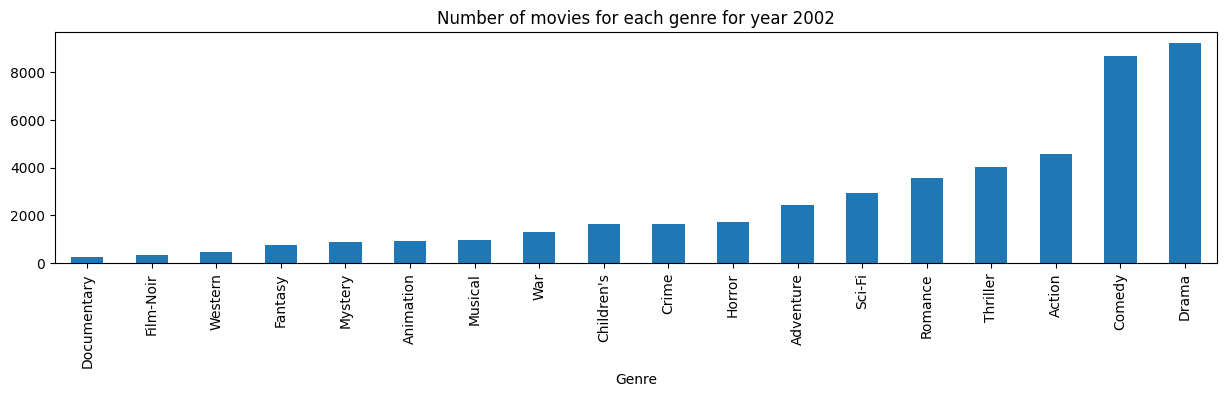

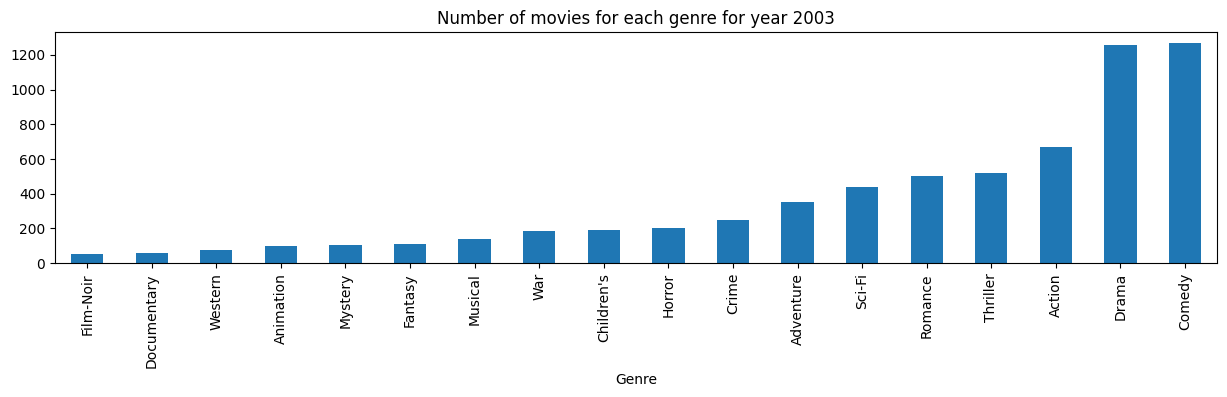

In [48]:
for year in df_final['year'].unique():
    df_year = df_final[df_final['year']==year]
    df_temp = pd.DataFrame(columns=['genre', 'num_movies'])
    for genre in genres_unique.genre:
        row = [genre, df_year[df_year[genre]==True][['movie_id']].count()]
        df_temp.loc[len(df_temp)] = row
    df_temp['num_movies'] = df_temp['num_movies'].astype(np.int32)
    df_temp = df_temp.sort_values('num_movies', ascending=True).set_index('genre')
    plot_fig = df_temp['num_movies'].plot(kind='bar', figsize=(15,3))
    plot_fig.set_title('Number of movies for each genre for year %s'%year)
    plot_fig.set_xlabel('Genre')
    plt.show()

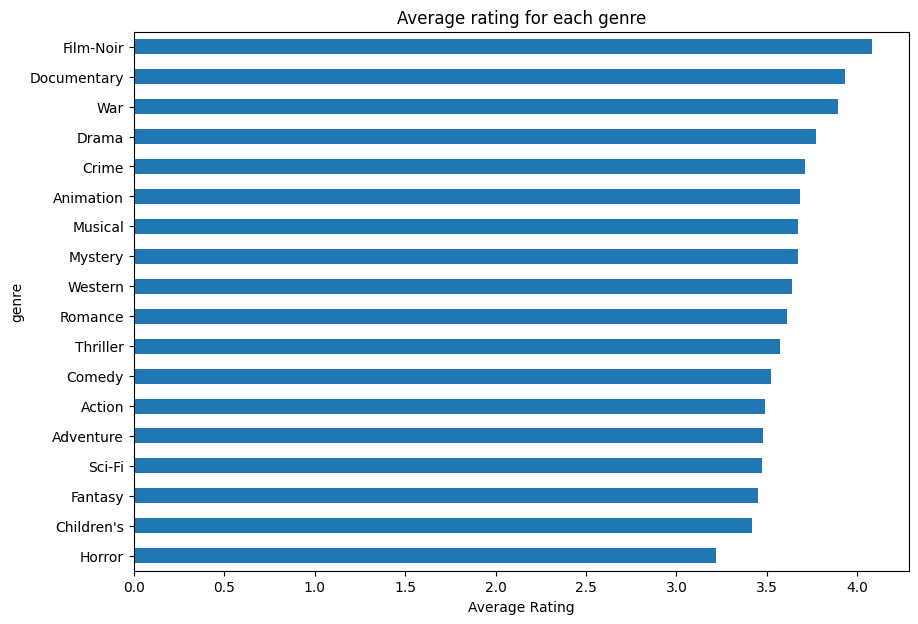

In [49]:
df_temp = pd.DataFrame(columns=['genre', 'avg_rating'])
for genre in genres_unique.genre:
    row = [genre, round(df_final[df_final[genre]==True][['rating']].mean(), 2).to_string()[6:]]
    df_temp.loc[len(df_temp)] = row
df_temp['avg_rating'] = pd.to_numeric(df_temp['avg_rating'])
df_temp = df_temp.sort_values('avg_rating', ascending=True).set_index('genre')
plot_fig = df_temp['avg_rating'].plot(kind='barh', figsize=(10,7))
plot_fig.set_title('Average rating for each genre')
plot_fig.set_xlabel('Average Rating');

In [50]:
print(round(df_final.groupby(['gender'])['rating'].mean(), 2))


gender
F    3.62
M    3.57
Name: rating, dtype: float64


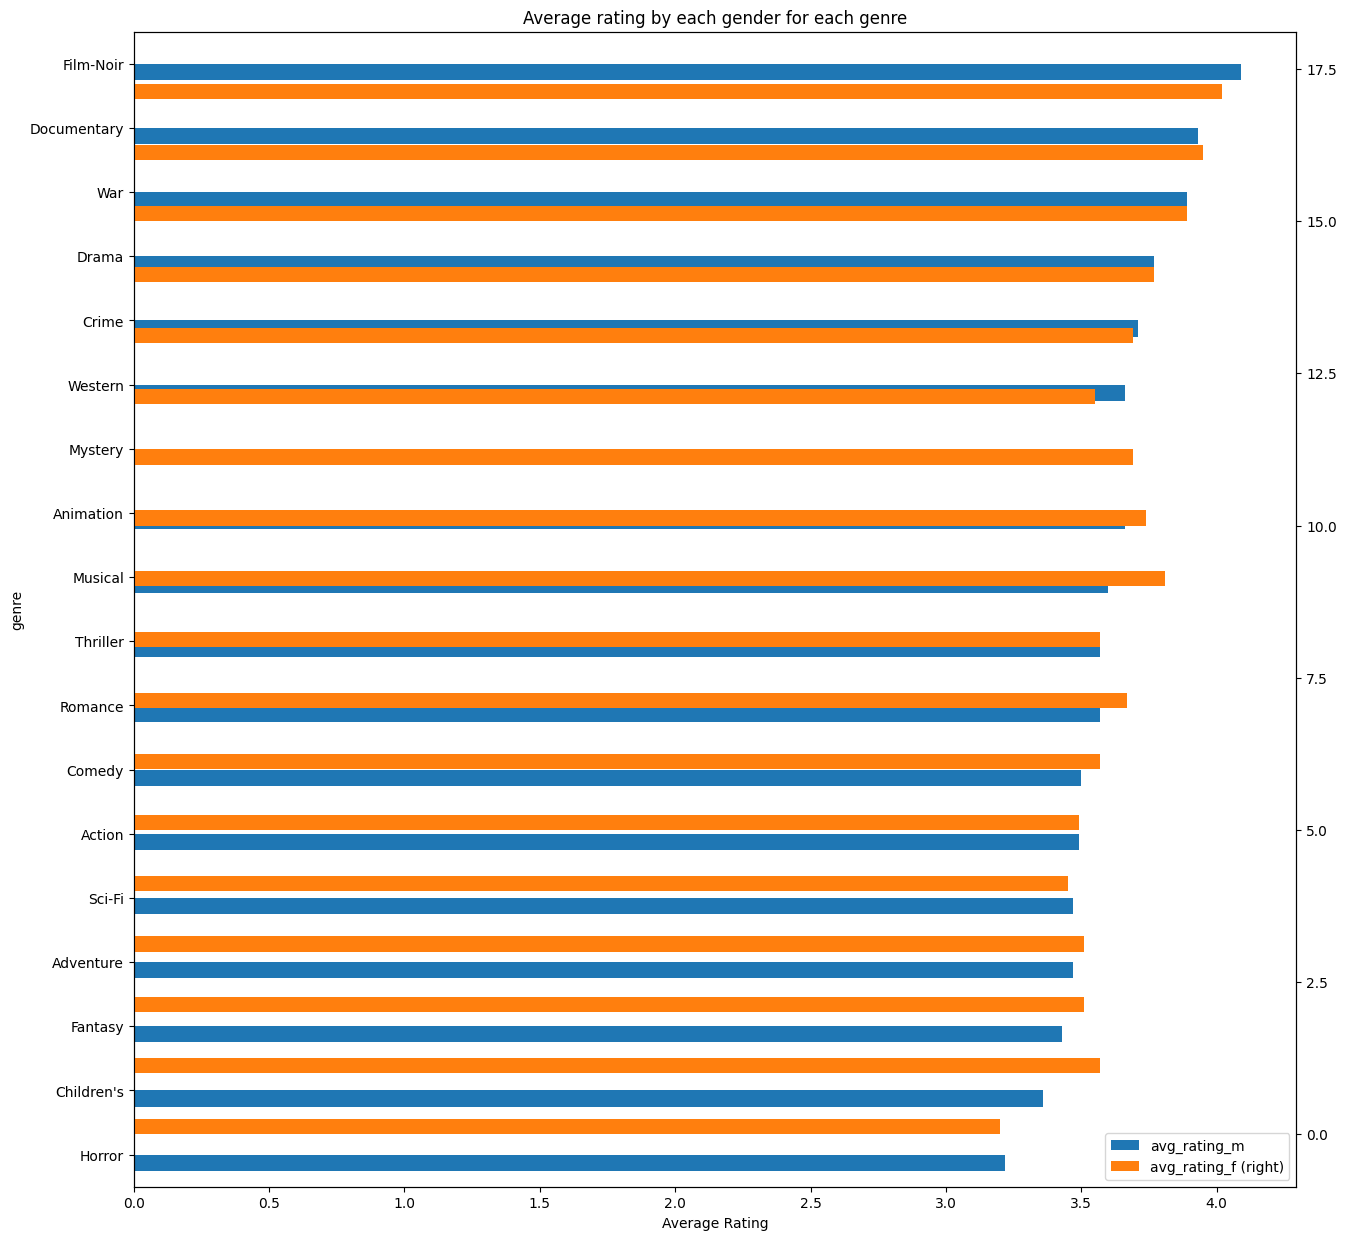

In [51]:
df_temp = pd.DataFrame(columns=['genre', 'avg_rating_m', 'avg_rating_f'])
for genre in genres_unique.genre:
    rating_m = round(df_final[(df_final[genre]==True) & (df_final['gender']=='M')][
        ['rating']].mean(), 2).to_string()[6:]
    rating_f = round(df_final[(df_final[genre]==True) & (df_final['gender']=='F')][
        ['rating']].mean(), 2).to_string()[6:]
    row = [genre, rating_m, rating_f]
    df_temp.loc[len(df_temp)] = row
    
cols = ['avg_rating_m', 'avg_rating_f']
df_temp[cols] = df_temp[cols].apply(pd.to_numeric, errors='coerce', axis=1)
df_temp = df_temp.sort_values('avg_rating_m', ascending=True).set_index('genre')
plot_fig = df_temp.plot( kind= 'barh' , secondary_y= 'avg_rating_f', figsize=(15,15))
plot_fig.set_title('Average rating by each gender for each genre')
plot_fig.set_xlabel('Average Rating');

In [52]:
print(round(df_final.groupby(['age'])['rating'].mean(), 2))


age
1     3.55
18    3.51
25    3.55
35    3.62
45    3.64
50    3.71
56    3.77
Name: rating, dtype: float64


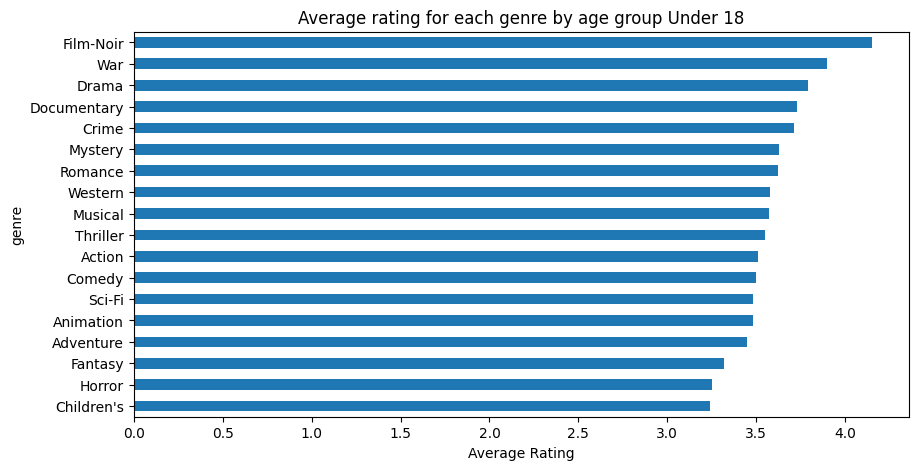

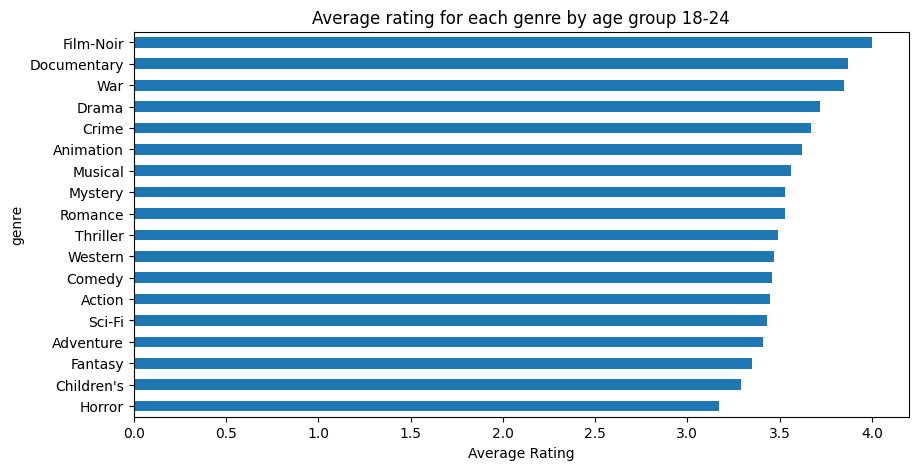

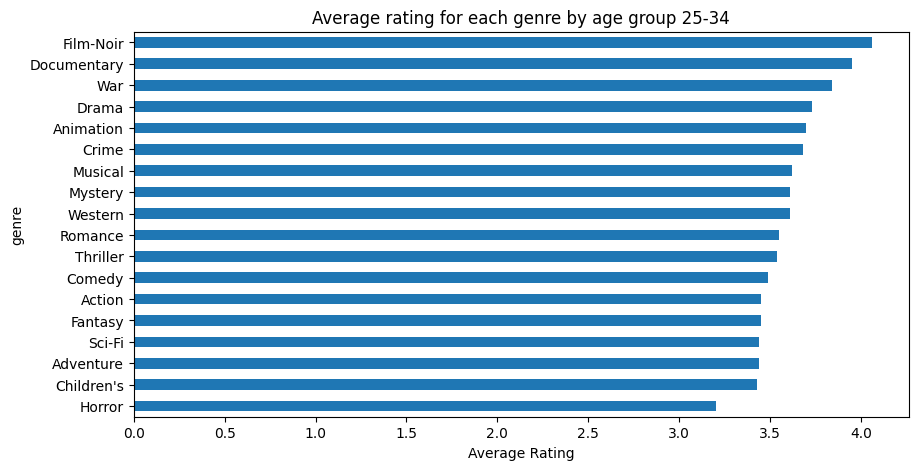

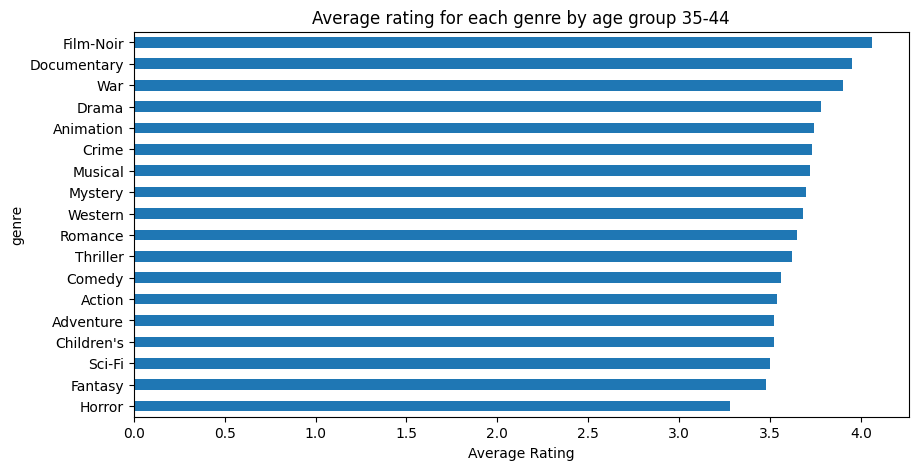

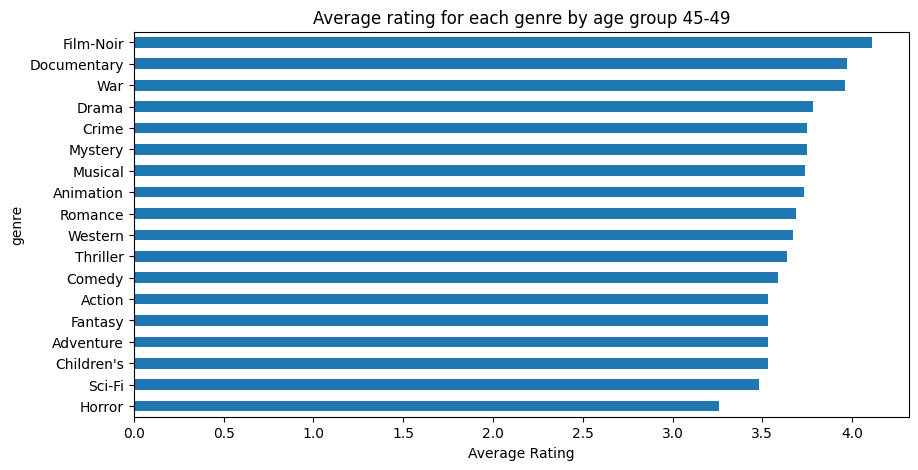

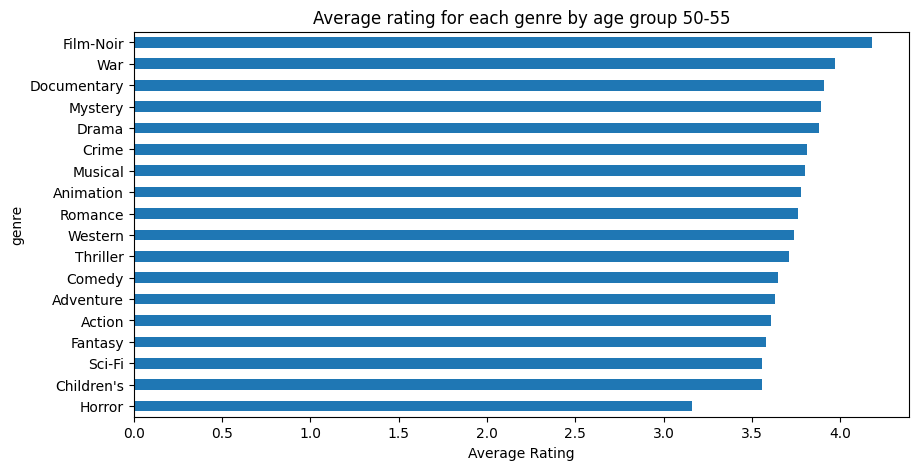

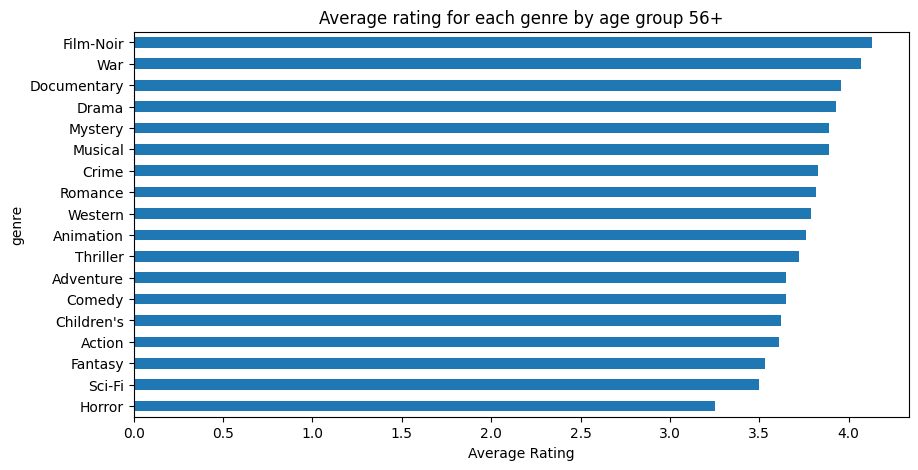

In [53]:
for age in sorted(df_user.age.unique()):
    df_temp = pd.DataFrame(columns=['genre', 'avg_rating'])
    df_final_temp = df_final[df_final['age']==age]
    for genre in genres_unique.genre:
        row = [genre, round(df_final_temp[df_final_temp[genre]==True][['rating']].mean(), 2).to_string()[6:]]
        df_temp.loc[len(df_temp)] = row
    df_temp['avg_rating'] = pd.to_numeric(df_temp['avg_rating'])
    df_temp = df_temp.sort_values('avg_rating', ascending=True).set_index('genre')
    plot_fig = df_temp['avg_rating'].plot(kind='barh', figsize=(10,5))
    plot_fig.set_title('Average rating for each genre by age group %s'%age_group_dict[age])
    plot_fig.set_xlabel('Average Rating')
    plt.show()

In [54]:
df_temp = pd.DataFrame(columns=['occupation', 'avg_rating'])
for occ in occupation_dict.keys():
    row = [occupation_dict[occ], round(df_final[df_final['occupation'] == occ]['rating'].mean(), 2)]
    df_temp.loc[len(df_temp)] = row
df_temp = df_temp.sort_values('avg_rating', ascending=False).reset_index(drop=True)
df_temp

,occupation,avg_rating
0,retired,3.78
1,scientist,3.69
2,clerical/admin,3.66
3,doctor/health care,3.66
4,homemaker,3.66
5,programmer,3.65
6,sales/marketing,3.62
7,lawyer,3.62
8,technician/engineer,3.61
9,self-employed,3.60


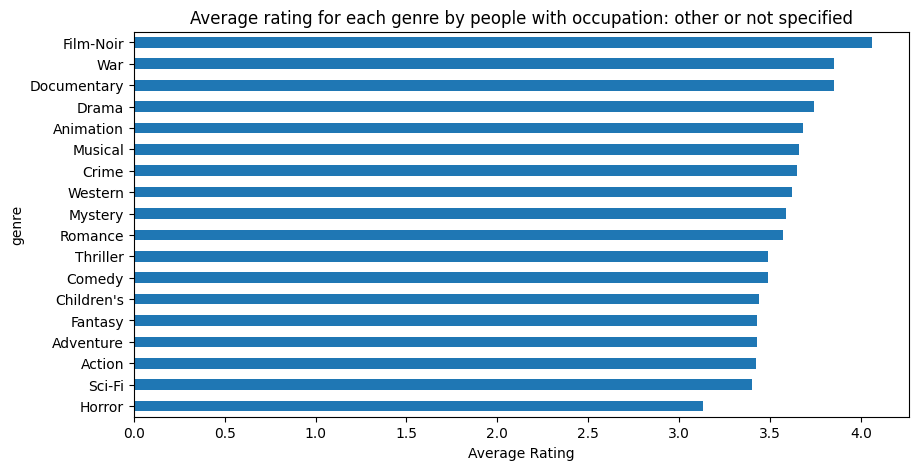

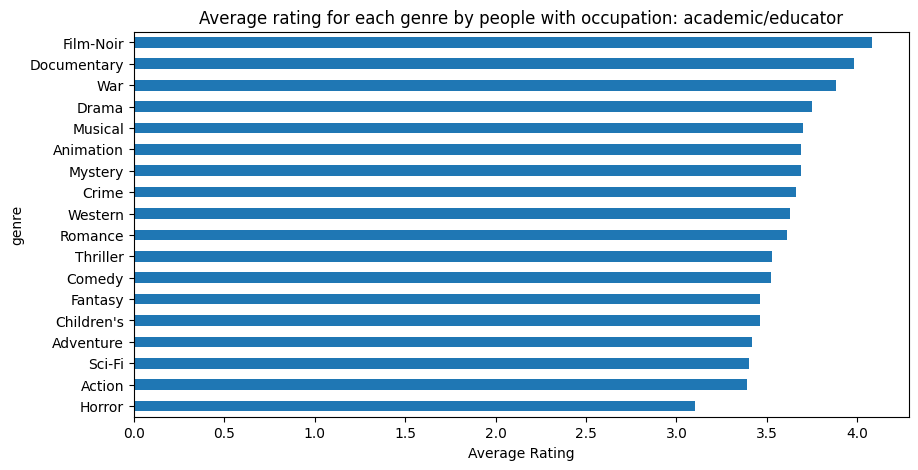

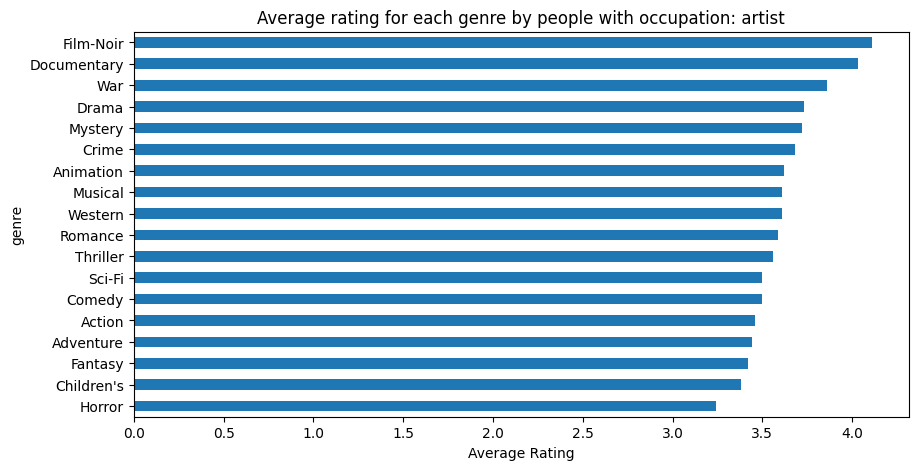

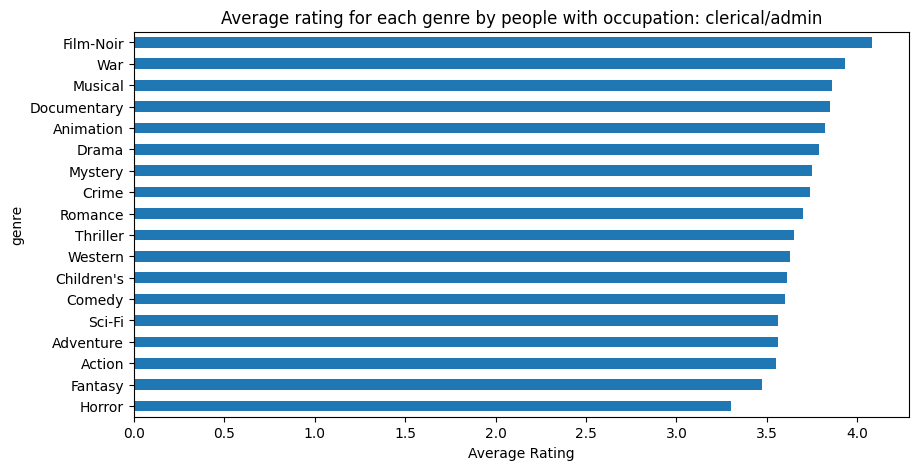

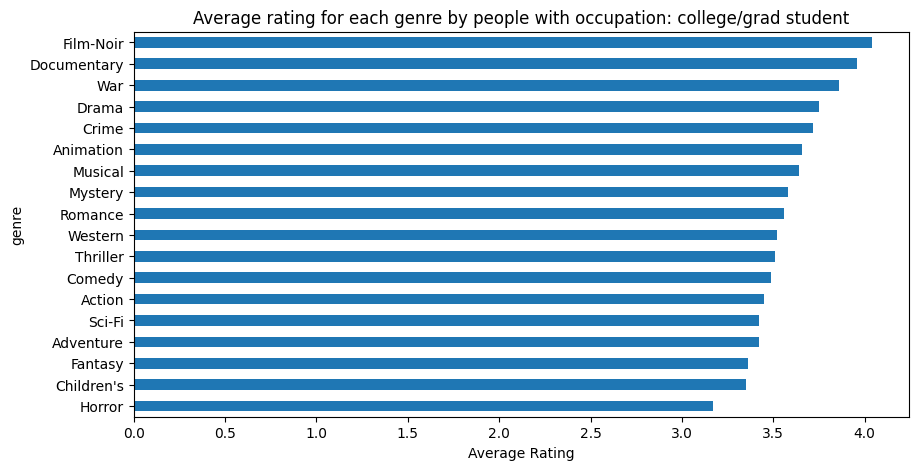

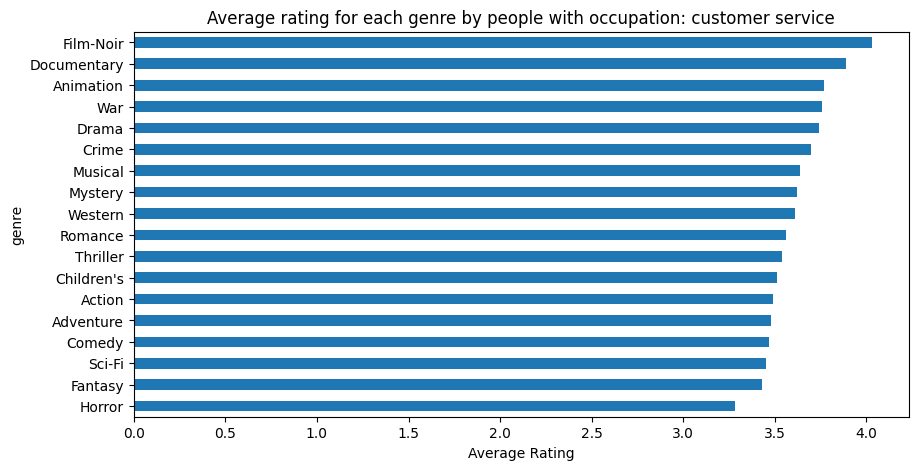

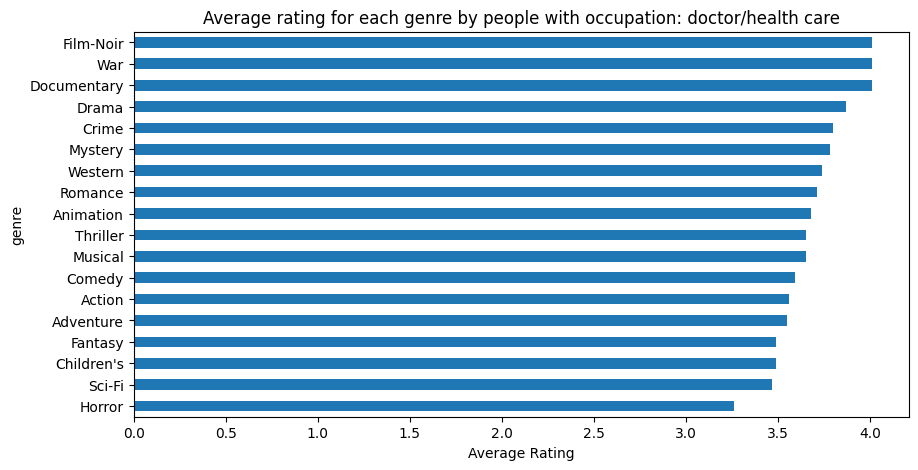

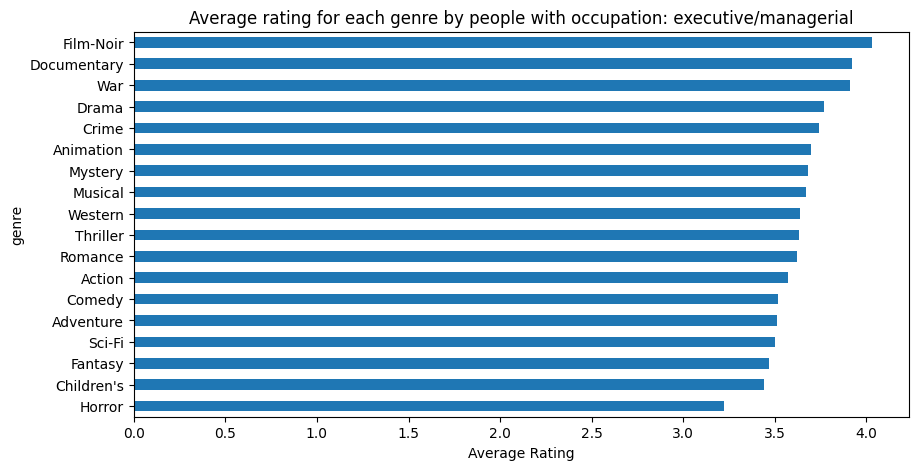

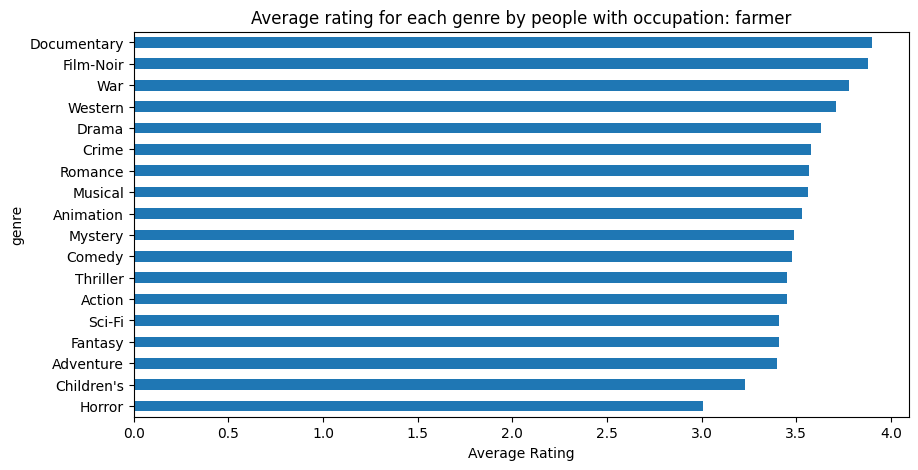

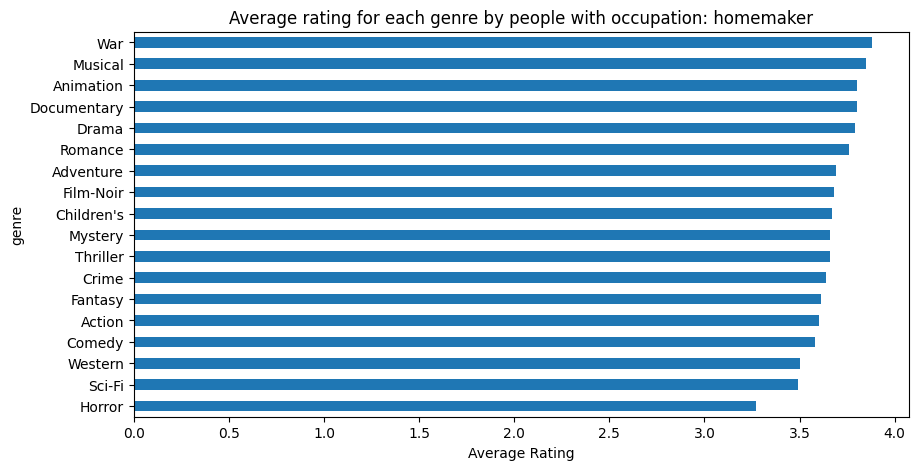

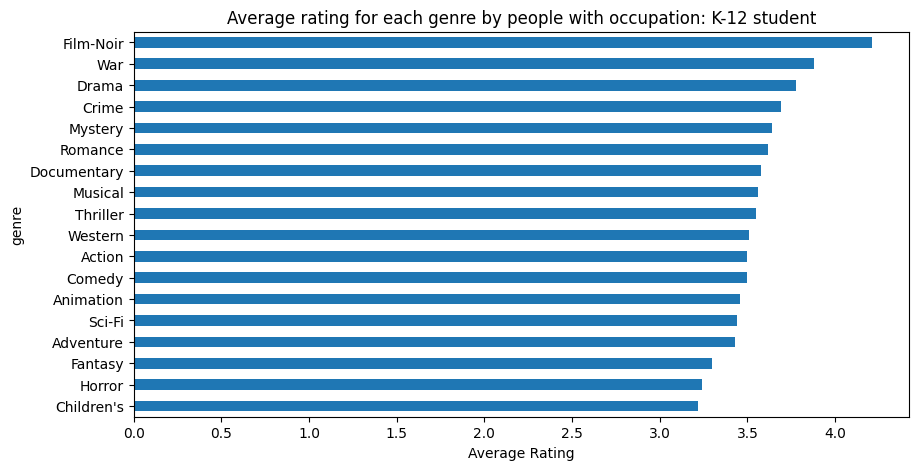

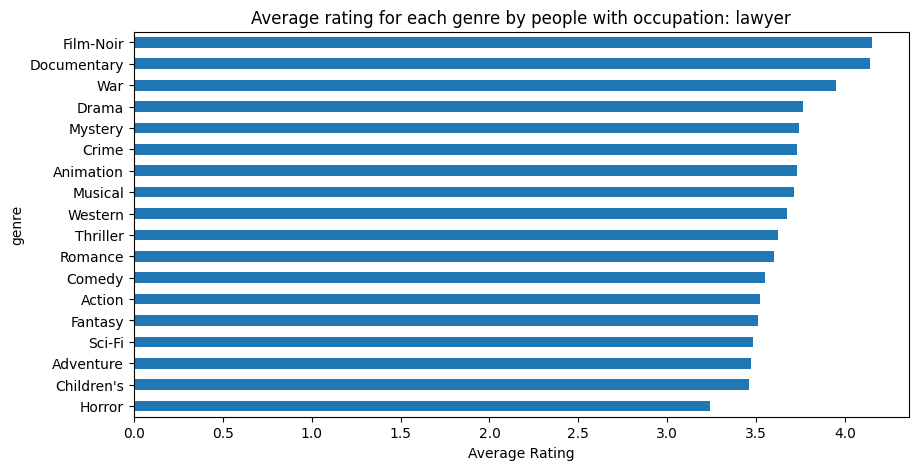

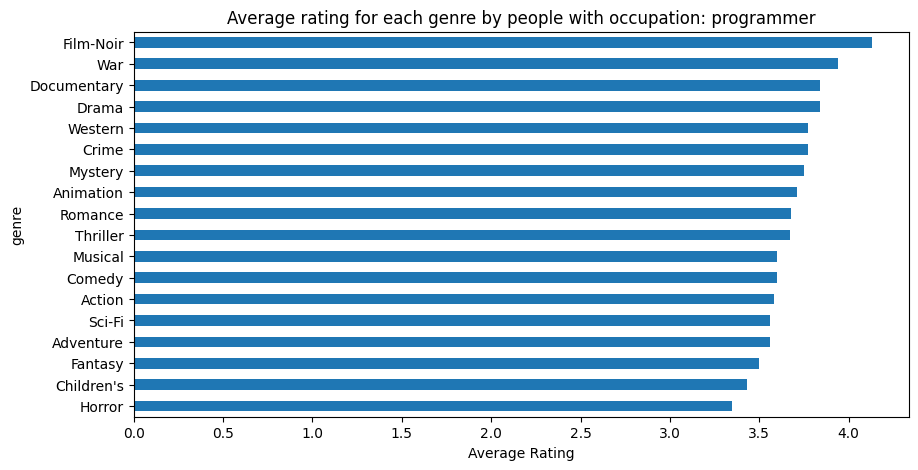

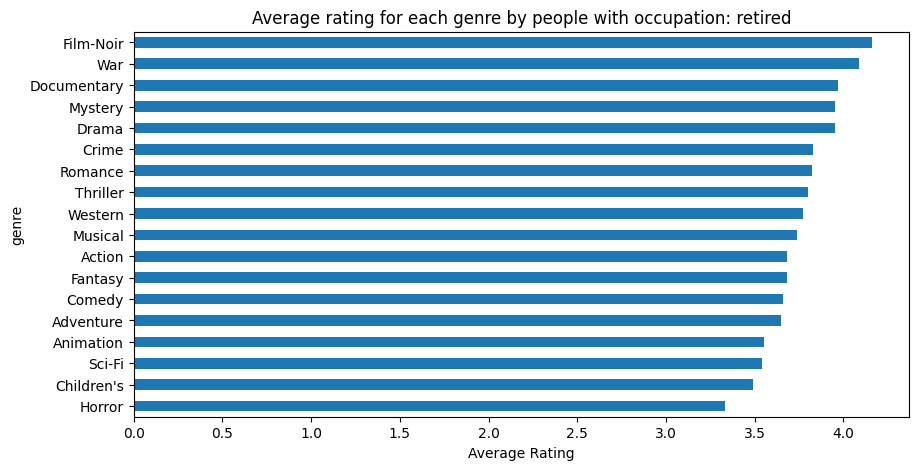

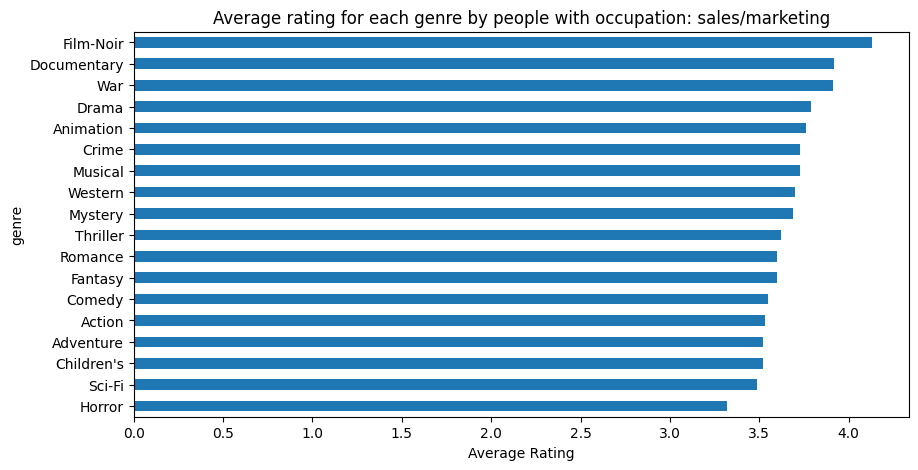

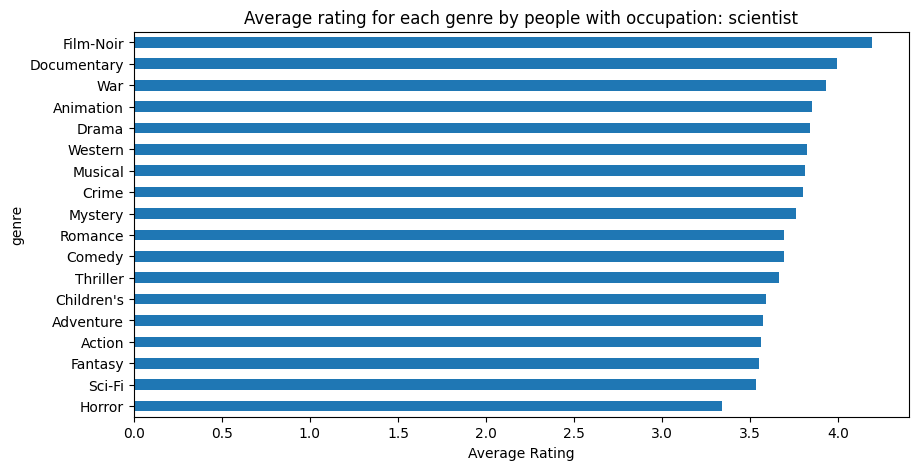

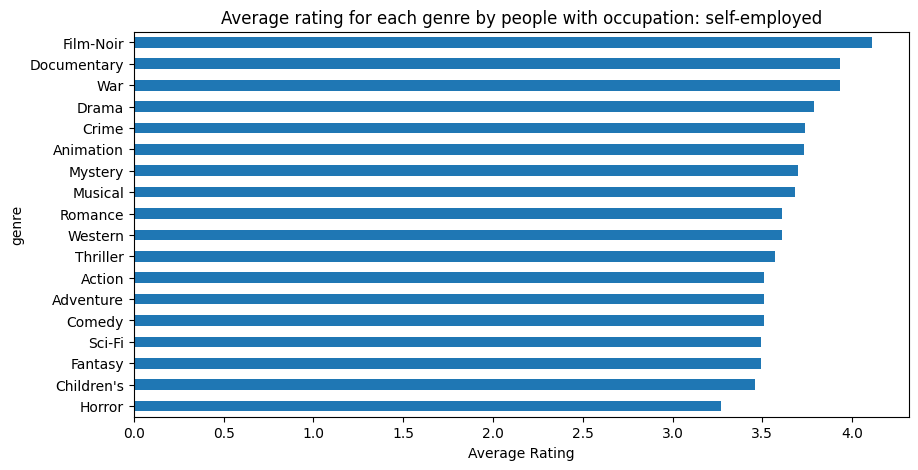

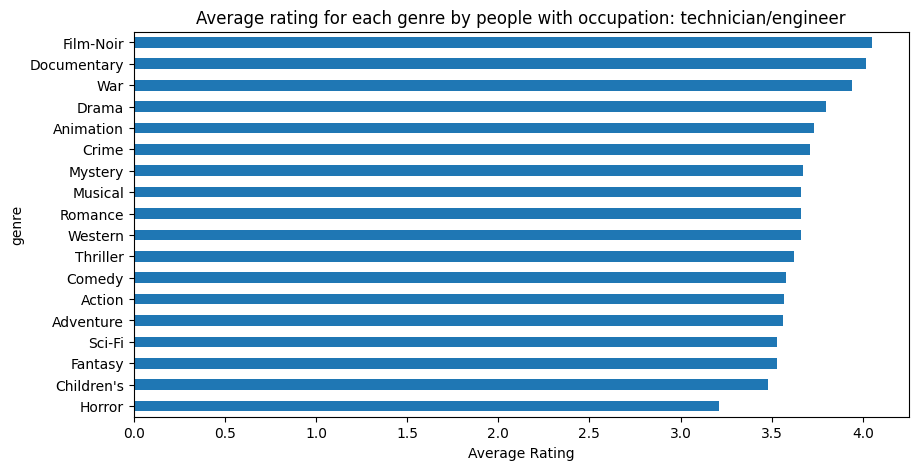

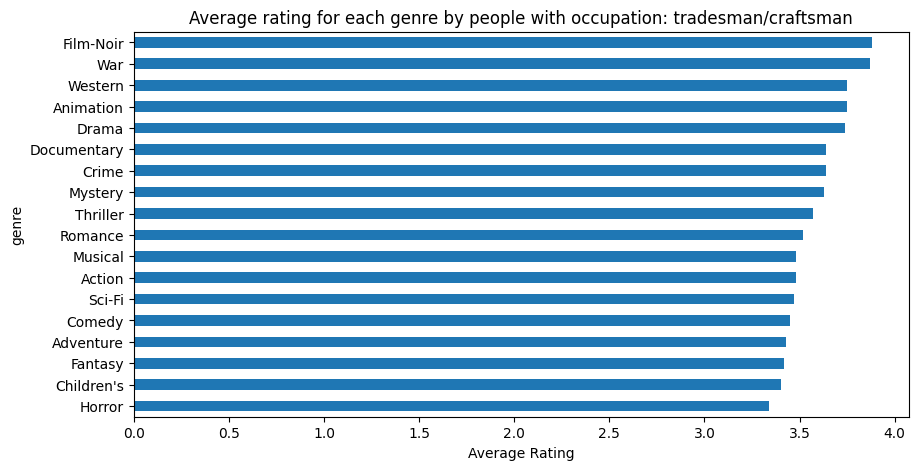

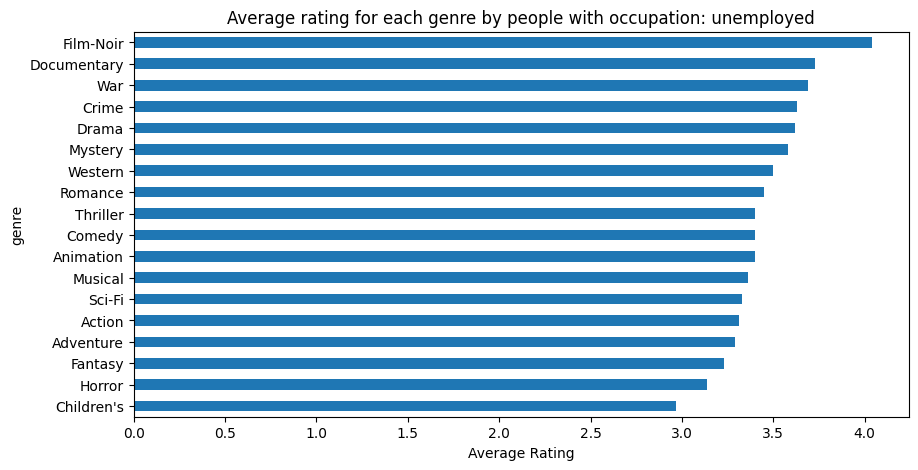

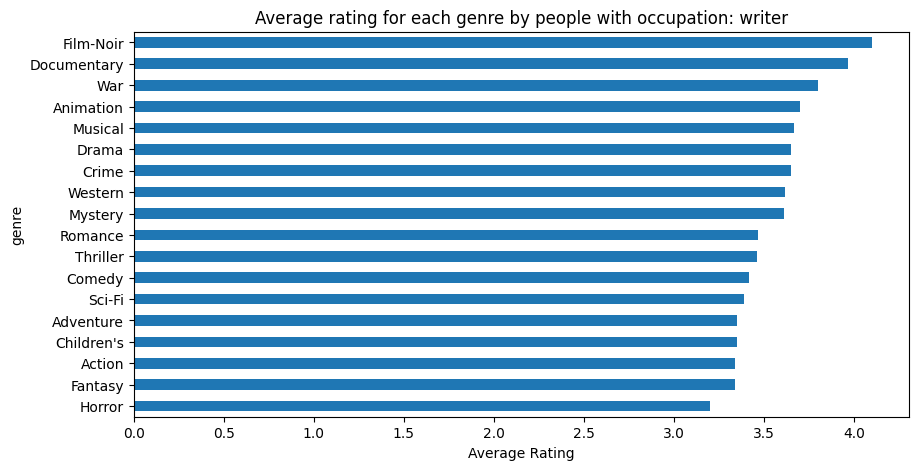

In [55]:
for occ in sorted(df_user.occupation.unique()):
    df_temp = pd.DataFrame(columns=['genre', 'avg_rating'])
    df_final_temp = df_final[df_final['occupation']==occ]
    for genre in genres_unique.genre:
        row = [genre, round(df_final_temp[df_final_temp[genre]==True][['rating']].mean(), 2).to_string()[6:]]
        df_temp.loc[len(df_temp)] = row
    df_temp['avg_rating'] = pd.to_numeric(df_temp['avg_rating'])
    df_temp = df_temp.sort_values('avg_rating', ascending=True).set_index('genre')
    plot_fig = df_temp['avg_rating'].plot(kind='barh', figsize=(10,5))
    plot_fig.set_title('Average rating for each genre by people with occupation: %s'%occupation_dict[occ])
    plot_fig.set_xlabel('Average Rating')
    plt.show()